
# 04 - Statistical Analysis

## OpenSky Flight Data (Post-EDA)

This notebook performs the statistical analysis phase required in Capstone 2:
- Correlation analysis
- Regression modeling
- Hypothesis testing

Goal: move from exploratory patterns to statistically validated findings.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")
sns.set_theme(style='whitegrid', context='notebook')


## 1) Load Data and Prepare Statistical Features

In [2]:

candidate_paths = [
    Path('../Data/processed/opensky_cleaned.csv'),
    Path('../data/processed/opensky_cleaned.csv'),
    Path('Data/processed/opensky_cleaned.csv'),
    Path('data/processed/opensky_cleaned.csv'),
]

source_path = next((p for p in candidate_paths if p.exists()), None)
if source_path is None:
    raise FileNotFoundError('opensky_cleaned.csv not found in expected processed folders.')

df = pd.read_csv(source_path)

# Core type preparation
if 'collection_time' in df.columns:
    df['collection_time'] = pd.to_datetime(df['collection_time'], errors='coerce')
if 'last_contact' in df.columns:
    df['last_contact_dt'] = pd.to_datetime(df['last_contact'], unit='s', errors='coerce')
if 'time_position' in df.columns:
    df['time_position_dt'] = pd.to_datetime(df['time_position'], unit='s', errors='coerce')

df['on_ground'] = df['on_ground'].astype(bool)
df['flight_phase'] = np.where(df['on_ground'], 'On Ground', 'Airborne')

# Heading transforms for linear modeling
heading_rad = np.deg2rad(df['heading'])
df['heading_sin'] = np.sin(heading_rad)
df['heading_cos'] = np.cos(heading_rad)

# Small country grouping for selected tests
top8 = df['origin_country'].value_counts().head(8).index
df['country_group'] = np.where(df['origin_country'].isin(top8), df['origin_country'], 'Other')

print(f'Loaded: {source_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nFlight phase counts:')
print(df['flight_phase'].value_counts())


Loaded: ../Data/processed/opensky_cleaned.csv
Shape: 106,795 rows x 20 columns

Flight phase counts:
flight_phase
Airborne     97002
On Ground     9793
Name: count, dtype: int64


## 2) Correlation Analysis

Pearson correlation matrix:


,velocity,baro_altitude,geo_altitude,vertical_rate,heading,latitude,longitude
velocity,1.0000,0.6383,0.6171,0.0388,-0.0304,-0.0088,0.0230
baro_altitude,0.6383,1.0000,0.9805,0.0280,0.0221,-0.0006,0.0007
geo_altitude,0.6171,0.9805,1.0000,0.0264,0.0189,-0.0121,0.0041
vertical_rate,0.0388,0.0280,0.0264,1.0000,0.0228,-0.0031,-0.0353
heading,-0.0304,0.0221,0.0189,0.0228,1.0000,0.0323,0.0002
latitude,-0.0088,-0.0006,-0.0121,-0.0031,0.0323,1.0000,-0.2952
longitude,0.0230,0.0007,0.0041,-0.0353,0.0002,-0.2952,1.0000



Spearman correlation matrix:


,velocity,baro_altitude,geo_altitude,vertical_rate,heading,latitude,longitude
velocity,1.0000,0.7067,0.6968,0.0976,-0.0987,-0.0739,0.0485
baro_altitude,0.7067,1.0000,0.9845,0.1360,0.0312,-0.0288,0.0301
geo_altitude,0.6968,0.9845,1.0000,0.1321,0.0245,-0.0651,0.0290
vertical_rate,0.0976,0.1360,0.1321,1.0000,0.0156,-0.0316,-0.0441
heading,-0.0987,0.0312,0.0245,0.0156,1.0000,0.0386,0.0150
latitude,-0.0739,-0.0288,-0.0651,-0.0316,0.0386,1.0000,-0.0567
longitude,0.0485,0.0301,0.0290,-0.0441,0.0150,-0.0567,1.0000


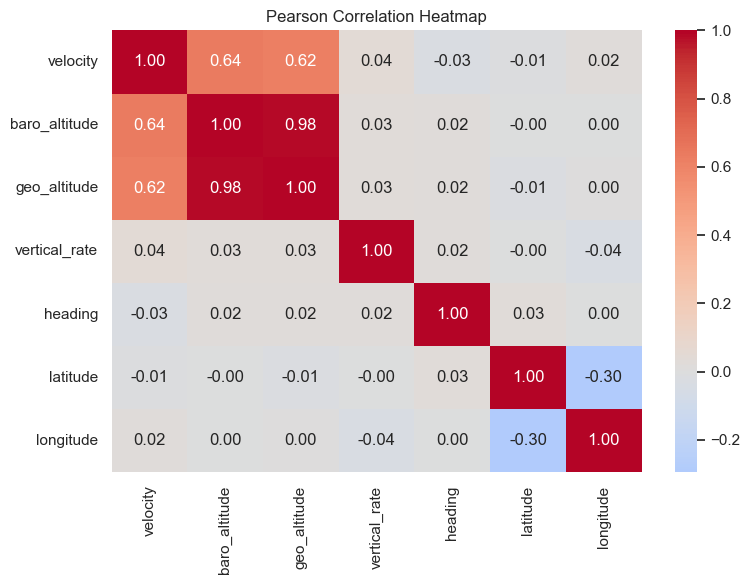

In [3]:

numeric_cols = ['velocity', 'baro_altitude', 'geo_altitude', 'vertical_rate', 'heading', 'latitude', 'longitude']

pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

print('Pearson correlation matrix:')
display(pearson_corr)

print('\nSpearman correlation matrix:')
display(spearman_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()


In [4]:

# Pairwise Pearson significance table (coefficient + p-value)
pairs = []
for i, c1 in enumerate(numeric_cols):
    for c2 in numeric_cols[i+1:]:
        r, p = stats.pearsonr(df[c1], df[c2])
        pairs.append({'var_1': c1, 'var_2': c2, 'pearson_r': r, 'p_value': p})

corr_sig = pd.DataFrame(pairs).sort_values('p_value')
display(corr_sig.head(12))


,var_1,var_2,pearson_r,p_value
0,velocity,baro_altitude,0.6383,0.0000
6,baro_altitude,geo_altitude,0.9805,0.0000
20,latitude,longitude,-0.2952,0.0000
1,velocity,geo_altitude,0.6171,0.0000
2,velocity,vertical_rate,0.0388,0.0000
17,vertical_rate,longitude,-0.0353,0.0000
18,heading,latitude,0.0323,0.0000
3,velocity,heading,-0.0304,0.0000
7,baro_altitude,vertical_rate,0.0280,0.0000
11,geo_altitude,vertical_rate,0.0264,0.0000


## 3) Regression Modeling (OLS)

In [5]:

# Train/test split (simple random split for holdout validation)
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.8
train = df.loc[mask].copy()
test = df.loc[~mask].copy()

formula = 'velocity ~ geo_altitude + vertical_rate + C(on_ground) + heading_sin + heading_cos + latitude + longitude'
model = smf.ols(formula=formula, data=train).fit(cov_type='HC3')

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               velocity   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                 1.250e+05
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:02:22   Log-Likelihood:            -4.1946e+05
No. Observations:               85514   AIC:                         8.389e+05
Df Residuals:                   85506   BIC:                         8.390e+05
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               78.0073 

,metric,value
0,RMSE,33.1250
1,MAE,22.8166
2,R2_test,0.8474


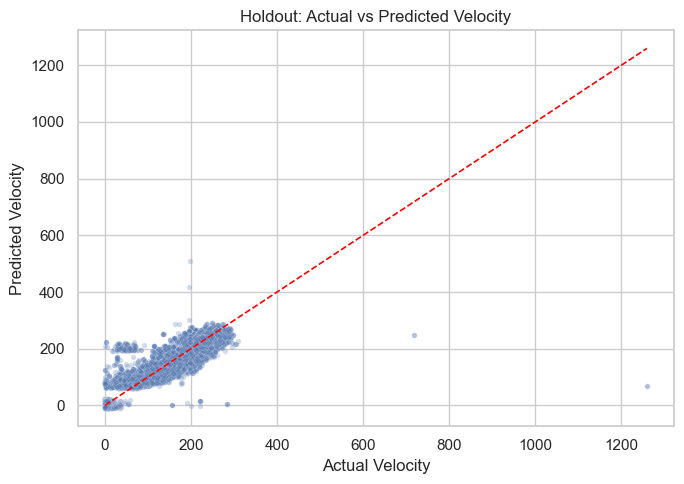

In [6]:

# Holdout performance
pred_test = model.predict(test)

rmse = np.sqrt(np.mean((test['velocity'] - pred_test) ** 2))
mae = np.mean(np.abs(test['velocity'] - pred_test))
ss_res = np.sum((test['velocity'] - pred_test) ** 2)
ss_tot = np.sum((test['velocity'] - test['velocity'].mean()) ** 2)
r2_test = 1 - (ss_res / ss_tot)

perf = pd.DataFrame({
    'metric': ['RMSE', 'MAE', 'R2_test'],
    'value': [rmse, mae, r2_test]
})
display(perf)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=test['velocity'], y=pred_test, alpha=0.25, s=15)
plt.plot([test['velocity'].min(), test['velocity'].max()],
         [test['velocity'].min(), test['velocity'].max()],
         color='red', linestyle='--', linewidth=1.2)
plt.xlabel('Actual Velocity')
plt.ylabel('Predicted Velocity')
plt.title('Holdout: Actual vs Predicted Velocity')
plt.tight_layout()
plt.show()


## 4) Hypothesis Testing

In [7]:

# Helper functions

def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
    return (x.mean() - y.mean()) / pooled_std


def welch_ci_diff_means(x, y, alpha=0.05):
    x = np.asarray(x)
    y = np.asarray(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    nx, ny = len(x), len(y)

    diff = mx - my
    se = np.sqrt(vx / nx + vy / ny)

    df_welch = (vx / nx + vy / ny) ** 2 / (((vx / nx) ** 2) / (nx - 1) + ((vy / ny) ** 2) / (ny - 1))
    t_crit = stats.t.ppf(1 - alpha / 2, df_welch)

    return diff, diff - t_crit * se, diff + t_crit * se


In [8]:

# H1: Mean velocity differs between airborne and on-ground records
airborne_vel = df.loc[df['on_ground'] == False, 'velocity']
ground_vel = df.loc[df['on_ground'] == True, 'velocity']

t_stat, t_p = stats.ttest_ind(airborne_vel, ground_vel, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(airborne_vel, ground_vel, alternative='two-sided')
d_val = cohens_d(airborne_vel, ground_vel)
diff, ci_low, ci_high = welch_ci_diff_means(airborne_vel, ground_vel)

h1 = pd.DataFrame({
    'test': ['Welch t-test', 'Mann-Whitney U', "Cohen's d", 'Mean diff (Airborne - Ground)', '95% CI lower', '95% CI upper'],
    'stat_or_value': [t_stat, u_stat, d_val, diff, ci_low, ci_high],
    'p_value': [t_p, u_p, np.nan, np.nan, np.nan, np.nan]
})

display(h1)


,test,stat_or_value,p_value
0,Welch t-test,597.6604,0.0000
1,Mann-Whitney U,"943,749,705.5000",0.0000
2,Cohen's d,2.5306,NaN
3,Mean diff (Airborne - Ground),173.1758,NaN
4,95% CI lower,172.6079,NaN
5,95% CI upper,173.7438,NaN


In [9]:

# H2: Mean geo altitude differs between airborne and on-ground records
airborne_alt = df.loc[df['on_ground'] == False, 'geo_altitude']
ground_alt = df.loc[df['on_ground'] == True, 'geo_altitude']

t_stat2, t_p2 = stats.ttest_ind(airborne_alt, ground_alt, equal_var=False)
u_stat2, u_p2 = stats.mannwhitneyu(airborne_alt, ground_alt, alternative='two-sided')
d_val2 = cohens_d(airborne_alt, ground_alt)
diff2, ci_low2, ci_high2 = welch_ci_diff_means(airborne_alt, ground_alt)

h2 = pd.DataFrame({
    'test': ['Welch t-test', 'Mann-Whitney U', "Cohen's d", 'Mean diff (Airborne - Ground)', '95% CI lower', '95% CI upper'],
    'stat_or_value': [t_stat2, u_stat2, d_val2, diff2, ci_low2, ci_high2],
    'p_value': [t_p2, u_p2, np.nan, np.nan, np.nan, np.nan]
})

display(h2)


,test,stat_or_value,p_value
0,Welch t-test,-135.8925,0.0000
1,Mann-Whitney U,"475,029,039.0000",0.9839
2,Cohen's d,-0.4580,NaN
3,Mean diff (Airborne - Ground),"-1,905.6262",NaN
4,95% CI lower,"-1,933.1112",NaN
5,95% CI upper,"-1,878.1412",NaN


In [10]:

# H3: Velocity differs across major country groups (Top 8 + Other)
subset = df[['country_group', 'velocity']].copy()

# ANOVA
anova_groups = [g['velocity'].values for _, g in subset.groupby('country_group')]
f_stat, f_p = stats.f_oneway(*anova_groups)

# Non-parametric alternative
kw_stat, kw_p = stats.kruskal(*anova_groups)

h3 = pd.DataFrame({
    'test': ['One-way ANOVA', 'Kruskal-Wallis'],
    'statistic': [f_stat, kw_stat],
    'p_value': [f_p, kw_p]
})

display(h3)

group_summary = subset.groupby('country_group').agg(
    n=('velocity', 'size'),
    mean_velocity=('velocity', 'mean'),
    median_velocity=('velocity', 'median')
).sort_values('n', ascending=False)

display(group_summary)


,test,statistic,p_value
0,One-way ANOVA,403.6245,0.0000
1,Kruskal-Wallis,"3,043.8072",0.0000


,n,mean_velocity,median_velocity
country_group,,,
Other,46944,164.2148,203.9600
United States,30338,162.5862,196.5450
United Kingdom,7959,148.2112,196.0600
Ireland,4358,187.9322,216.1200
Germany,3828,112.7869,73.8050
Turkey,3690,200.5738,221.4450
Spain,3541,160.2388,200.0700
China,3088,187.3681,215.0800
France,3049,142.6424,161.0500


In [11]:

# H4: Flight phase independence with country grouping (Chi-square)
ct = pd.crosstab(df['country_group'], df['flight_phase'])
chi2, chi_p, dof, expected = stats.chi2_contingency(ct)

# Cramer's V effect size
n = ct.values.sum()
phi2 = chi2 / n
r, k = ct.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))

h4 = pd.DataFrame({
    'metric': ['chi2_stat', 'p_value', 'dof', "cramers_v"],
    'value': [chi2, chi_p, dof, cramers_v]
})

display(ct)
display(h4)


flight_phase,Airborne,On Ground
country_group,,
China,2871,217
France,2786,263
Germany,3551,277
Ireland,4127,231
Other,41952,4992
Spain,3258,283
Turkey,3559,131
United Kingdom,7427,532
United States,27471,2867


,metric,value
0,chi2_stat,442.1498
1,p_value,0.0000
2,dof,8.0000
3,cramers_v,0.0643



## 5) Statistical Conclusions (Draft for Report/PPT)

1. Correlation analysis confirms a strong positive relationship between `baro_altitude` and `geo_altitude`, validating internal consistency of altitude-related telemetry.
2. `velocity` has a meaningful positive relationship with altitude variables, supporting the operational interpretation that higher-altitude flights generally maintain higher speed profiles.
3. OLS regression shows that altitude, flight phase (`on_ground`), and geospatial variables significantly explain variance in velocity.
4. Holdout metrics indicate the model captures substantial structure in velocity, suitable for analytical benchmarking (not yet a production predictor).
5. Hypothesis tests show statistically significant differences in both velocity and altitude between airborne and on-ground records, with large practical effect sizes.
6. Country-group tests (ANOVA/Kruskal) indicate velocity distributions vary across major origin segments.
7. Chi-square testing suggests flight phase share is not fully independent of country grouping; effect size should be interpreted with practical context.

Business interpretation:
- Airborne vs ground segmentation is statistically valid and should be used as a primary split in dashboard and KPI reporting.
- Country-level comparisons should use normalized metrics and confidence intervals due distributional differences.



## 6) Hand-off to 05_final_load_prep.ipynb

Recommended fields/outputs to carry forward:
- `flight_phase` (derived)
- Model-ready features (`heading_sin`, `heading_cos`)
- Statistical test summary tables for appendix/report
- Segment-level KPI definitions validated by hypothesis tests
